# Assignment 1: Log Mel Filter Banks & Speech Classification

In [1]:
# Install dependencies (safe to run locally too)
!pip install torchaudio thop -q

In [16]:
import os
import time
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F_nn
from torchaudio import functional as F_audio
from torchaudio.datasets import SPEECHCOMMANDS
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional
from matplotlib import font_manager
from tqdm.auto import tqdm

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


## Part 1: LogMelFilterBanks

In [3]:
class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super(LogMelFilterBanks, self).__init__()
        self.n_fft = n_fft
        self.samplerate = samplerate
        self.window_length = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.center = center
        self.return_complex = return_complex
        self.onesided = onesided
        self.normalize_stft = normalize_stft
        self.pad_mode = pad_mode
        self.power = power
        self.f_min_hz = f_min_hz
        self.f_max_hz = f_max_hz if f_max_hz is not None else samplerate / 2.0
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale

        # Register as buffers so they move to GPU automatically with .to(device)
        self.register_buffer('window', torch.hann_window(self.window_length))
        self.register_buffer('mel_fbanks', self._init_melscale_fbanks())

    def _init_melscale_fbanks(self):
        return F_audio.melscale_fbanks(
            n_freqs=self.n_fft // 2 + 1,
            f_min=self.f_min_hz,
            f_max=self.f_max_hz,
            n_mels=self.n_mels,
            sample_rate=self.samplerate,
            norm=self.norm_mel,
            mel_scale=self.mel_scale,
        )

    def spectrogram(self, x):
        return torch.stft(
            x,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.window_length,
            window=self.window,
            center=self.center,
            pad_mode=self.pad_mode,
            normalized=self.normalize_stft,
            onesided=self.onesided,
            return_complex=self.return_complex,
        )

    def forward(self, x):
        """
        Args:
            x: (batch, time) audio signal
        Returns:
            (batch, n_mels, n_frames) log mel filterbanks
        """
        spec = self.spectrogram(x)                  # (batch, n_freqs, n_frames) complex
        power_spec = torch.abs(spec) ** self.power  # (batch, n_freqs, n_frames)
        # mel_fbanks: (n_freqs, n_mels) -> .T: (n_mels, n_freqs)
        mel_spec = torch.matmul(self.mel_fbanks.T, power_spec)  # (batch, n_mels, n_frames)
        return torch.log(mel_spec + 1e-6)

### Verification: compare with `torchaudio.transforms.MelSpectrogram`

Shapes match : True  torch.Size([1, 80, 101])
Values close : True
Max abs diff : 9.54e-07


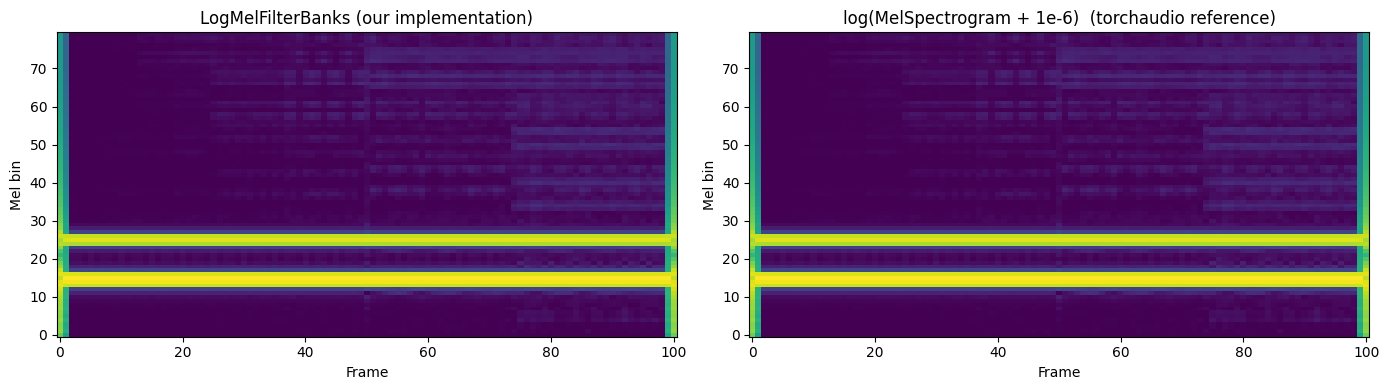

In [4]:
sr = 16000
t = torch.linspace(0, 1, sr)
signal = (torch.sin(2 * np.pi * 440 * t) + 0.5 * torch.sin(2 * np.pi * 880 * t)).unsqueeze(0)  # (1, 16000)

melspec_transform = torchaudio.transforms.MelSpectrogram(hop_length=160, n_mels=80)
melspec = melspec_transform(signal)
ref = torch.log(melspec + 1e-6)

logmel_transform = LogMelFilterBanks()
logmelbanks = logmel_transform(signal)

print(f'Shapes match : {ref.shape == logmelbanks.shape}  {ref.shape}')
print(f'Values close : {torch.allclose(ref, logmelbanks, atol=1e-5)}')
print(f'Max abs diff : {(ref - logmelbanks).abs().max().item():.2e}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(logmelbanks[0].detach().numpy(), aspect='auto', origin='lower')
axes[0].set_title('LogMelFilterBanks (our implementation)')
axes[0].set_xlabel('Frame'); axes[0].set_ylabel('Mel bin')
axes[1].imshow(ref[0].detach().numpy(), aspect='auto', origin='lower')
axes[1].set_title('log(MelSpectrogram + 1e-6)  (torchaudio reference)')
axes[1].set_xlabel('Frame'); axes[1].set_ylabel('Mel bin')
plt.tight_layout()
plt.savefig('part1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 2: Dataset — YES / NO binary classification

In [6]:
DATA_ROOT = './data'

class YesNoDataset(SPEECHCOMMANDS):
    LABELS = {'no': 0, 'yes': 1}
    TARGET_LENGTH = 16000  # 1 second at 16 kHz

    def __init__(self, root=DATA_ROOT, subset='training', download=True):
        super().__init__(root, download=download, subset=subset)
        self._walker = [
            w for w in self._walker
            if os.path.basename(os.path.dirname(w)) in self.LABELS
        ]

    def __getitem__(self, idx):
        waveform, sample_rate, label, *_ = super().__getitem__(idx)
        waveform = self._pad_or_trim(waveform)
        return waveform.squeeze(0), self.LABELS[label]  # (time,), int

    @staticmethod
    def _pad_or_trim(waveform):
        length = waveform.shape[-1]
        target = YesNoDataset.TARGET_LENGTH
        if length > target:
            return waveform[..., :target]
        if length < target:
            return F_nn.pad(waveform, (0, target - length))
        return waveform


print('Loading dataset (downloading if needed)...')
train_dataset = YesNoDataset(subset='training')
val_dataset   = YesNoDataset(subset='validation')
test_dataset  = YesNoDataset(subset='testing')
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Loading dataset (downloading if needed)...


100%|██████████| 2.26G/2.26G [00:15<00:00, 154MB/s]


Train: 6358, Val: 803, Test: 824


In [7]:
BATCH_SIZE = 64
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(device == 'cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device == 'cuda'))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device == 'cuda'))

x_batch, y_batch = next(iter(train_loader))
print(f'Waveform batch : {x_batch.shape}  (batch, time)')
print(f'Label batch    : {y_batch.shape}  values: {y_batch.unique().tolist()}')

Waveform batch : torch.Size([64, 16000])  (batch, time)
Label batch    : torch.Size([64])  values: [0, 1]


## Part 3: Model

In [8]:
class SpeechCNN(nn.Module):
    """
    Simple architecture: LogMelFilterBanks - 3x Conv1d - AdaptiveAvgPool - Linear
    """
    def __init__(self, n_mels: int = 80, groups: int = 1):
        super().__init__()
        self.feature_extractor = LogMelFilterBanks(n_mels=n_mels)
        self.backbone = nn.Sequential(
            nn.Conv1d(n_mels, 64,  kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64,    64,  kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64,    128, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(128, 2)

    def forward(self, x):
        features = self.feature_extractor(x)  # (batch, n_mels, n_frames)
        out = self.backbone(features)          # (batch, 128, 1)
        out = out.squeeze(-1)                  # (batch, 128)
        return self.classifier(out)            # (batch, 2)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def count_backbone_parameters(self):
        trainable = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)
        return trainable(self.backbone) + trainable(self.classifier)


# Sanity check
model = SpeechCNN(n_mels=80, groups=1).to(device)
dummy = torch.zeros(2, 16000).to(device)
out = model(dummy)
print(f'Output shape     : {out.shape}  (batch, 2 classes)')
print(f'Total params     : {model.count_parameters():,}')
print(f'Backbone params  : {model.count_backbone_parameters():,}')

Output shape     : torch.Size([2, 2])  (batch, 2 classes)
Total params     : 53,250
Backbone params  : 53,250


In [9]:
try:
    from thop import profile as thop_profile
    n_frames = 101
    dummy_mel = torch.zeros(1, 80, n_frames)
    flops, params = thop_profile(model.backbone, inputs=(dummy_mel.to(device),), verbose=False)
    print(f'Backbone FLOPs  : {flops / 1e6:.2f} M')
    print(f'Backbone params : {params / 1e3:.2f} K')
except Exception as e:
    print(f'thop error: {e}')
    print(f'Backbone params (manual): {model.count_backbone_parameters():,}')

Backbone FLOPs  : 4.11 M
Backbone params : 52.99 K


## Part 4: Training pipeline

In [19]:
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    start = time.time()
    pbar = tqdm(loader, desc='train', leave=False)
    for waveform, labels in pbar:
        waveform, labels = waveform.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(waveform), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * waveform.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    return total_loss / len(loader.dataset), time.time() - start


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    for waveform, labels in loader:
        waveform, labels = waveform.to(device), labels.to(device)
        preds = model(waveform).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total

In [20]:
def run_experiment(n_mels=80, groups=1, epochs=10, lr=1e-3):
    model = SpeechCNN(n_mels=n_mels, groups=groups).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_acc': [], 'epoch_time': []}

    print(f'n_mels={n_mels}, groups={groups} | params={model.count_parameters():,}')
    for epoch in range(1, epochs + 1):
        train_loss, epoch_time = train_epoch(model, train_loader, optimizer)
        val_acc = evaluate(model, val_loader)
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_time)
        print(f'  Epoch {epoch:2d}/{epochs}  loss={train_loss:.4f}  val_acc={val_acc:.4f}  time={epoch_time:.1f}s')

    test_acc = evaluate(model, test_loader)
    print(f'  => Test accuracy: {test_acc:.4f}')
    return model, history, test_acc

## Part 5: Experiment — varying `n_mels`

Fix `groups=1`, vary `n_mels` ∈ {20, 40, 80}.

In [26]:
import sys, io

class StderrFilter(io.TextIOWrapper):
    IGNORE = ('can only test a child process', '_shutdown_workers', 'is_alive')

    def __init__(self):
        self._real_stderr = sys.__stderr__

    def write(self, text):
        if not any(kw in text for kw in self.IGNORE):
            self._real_stderr.write(text)

    def flush(self):
        self._real_stderr.flush()

sys.stderr = StderrFilter()

In [29]:
EPOCHS = 20

In [30]:
N_MELS_LIST = [20, 40, 80]
n_mels_results = {}

for n_mels in N_MELS_LIST:
    print(f'\n=== n_mels={n_mels} ===')
    _, history, test_acc = run_experiment(n_mels=n_mels, groups=1, epochs=EPOCHS)
    n_mels_results[n_mels] = {'history': history, 'test_acc': test_acc}


=== n_mels=20 ===
n_mels=20, groups=1 | params=41,730


train:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch  1/20  loss=0.1959  val_acc=0.9564  time=21.4s


train:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch  2/20  loss=0.1076  val_acc=0.9676  time=22.0s


...

  Epoch 18/20  loss=0.0360  val_acc=0.9763  time=24.9s


train:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch 19/20  loss=0.0312  val_acc=0.9863  time=24.6s


train:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch 20/20  loss=0.0282  val_acc=0.9614  time=23.6s
  => Test accuracy: 0.9502


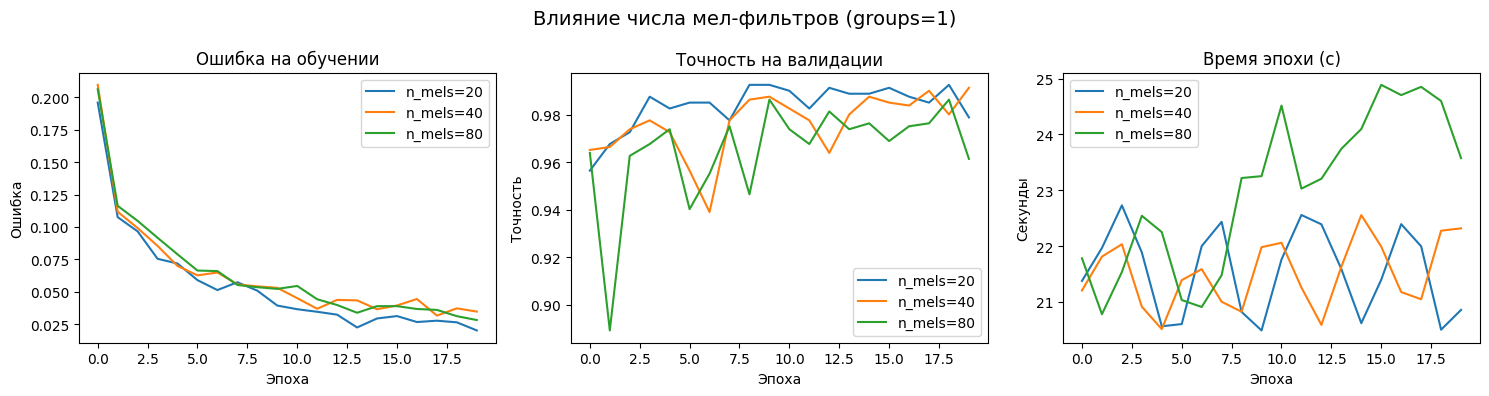

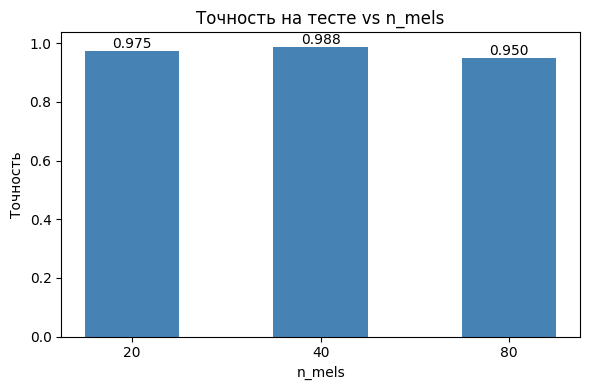

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Влияние числа мел-фильтров (groups=1)', fontsize=14)

for n_mels, result in n_mels_results.items():
    h = result['history']
    axes[0].plot(h['train_loss'],  label=f'n_mels={n_mels}')
    axes[1].plot(h['val_acc'],     label=f'n_mels={n_mels}')
    axes[2].plot(h['epoch_time'],  label=f'n_mels={n_mels}')

for ax, title, ylabel in zip(axes,
      ['Ошибка на обучении', 'Точность на валидации', 'Время эпохи (с)'],
      ['Ошибка', 'Точность', 'Секунды']):
      ax.set_title(title); ax.set_xlabel('Эпоха'); ax.set_ylabel(ylabel); ax.legend()

plt.tight_layout()
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.savefig('n_mels_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Test accuracy bar chart
test_accs = [n_mels_results[m]['test_acc'] for m in N_MELS_LIST]
fig2, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([str(m) for m in N_MELS_LIST], test_accs, color='steelblue', width=0.5)
ax.set_title('Точность на тесте vs n_mels')
ax.set_xlabel('n_mels'); ax.set_ylabel('Точность')
for bar, v in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.savefig('n_mels_test_acc.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 6: Experiment — varying `groups` in Conv1d

Fix `n_mels=80`, vary `groups` ∈ {1, 2, 4, 8, 16}.  
Note: `groups` must divide both `in_channels` and `out_channels`.  
With n_mels=80 and channels 64/128, all values {1,2,4,8,16} satisfy this.

In [32]:
GROUPS_LIST = [1, 2, 4, 8, 16]
groups_results = {}

for groups in GROUPS_LIST:
    print(f'\n=== groups={groups} ===')
    tmp_model = SpeechCNN(n_mels=80, groups=groups)
    backbone_params = tmp_model.count_backbone_parameters()

    # FLOPs for the backbone
    try:
        from thop import profile as thop_profile
        dummy_mel = torch.zeros(1, 80, 101)
        flops, _ = thop_profile(tmp_model.backbone, inputs=(dummy_mel,), verbose=False)
    except Exception:
        flops = None

    _, history, test_acc = run_experiment(n_mels=80, groups=groups, epochs=EPOCHS)
    groups_results[groups] = {
        'history': history,
        'test_acc': test_acc,
        'backbone_params': backbone_params,
        'flops': flops,
    }


=== groups=1 ===
n_mels=80, groups=1 | params=53,250


train:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch  1/20  loss=0.2046  val_acc=0.9564  time=21.6s


train:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch  2/20  loss=0.1201  val_acc=0.9601  time=21.9s


...

  Epoch 18/20  loss=0.1082  val_acc=0.9502  time=25.5s


train:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch 19/20  loss=0.1008  val_acc=0.9427  time=25.8s


train:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch 20/20  loss=0.1011  val_acc=0.9290  time=25.8s
  => Test accuracy: 0.9284


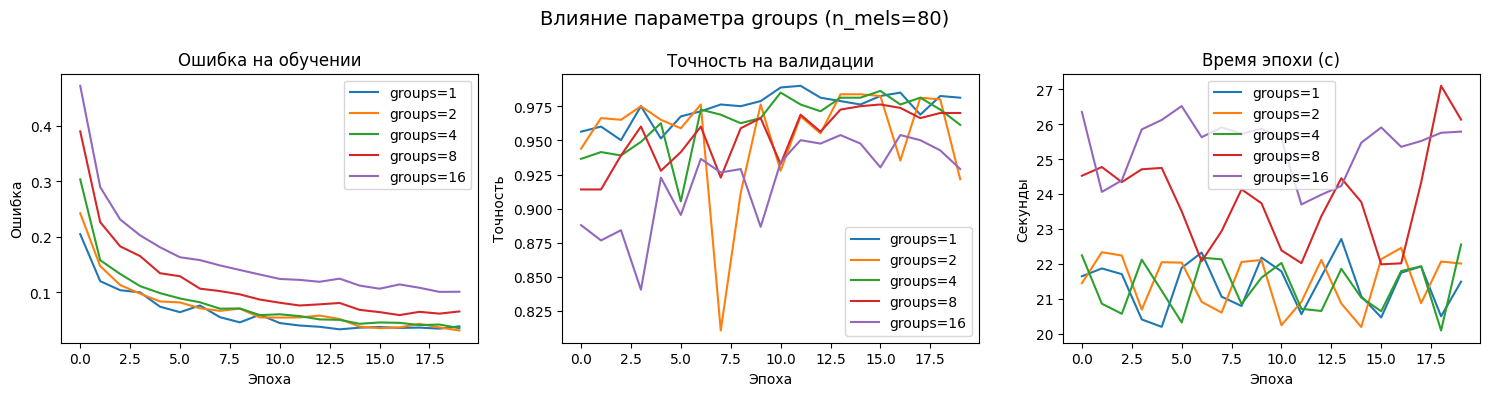

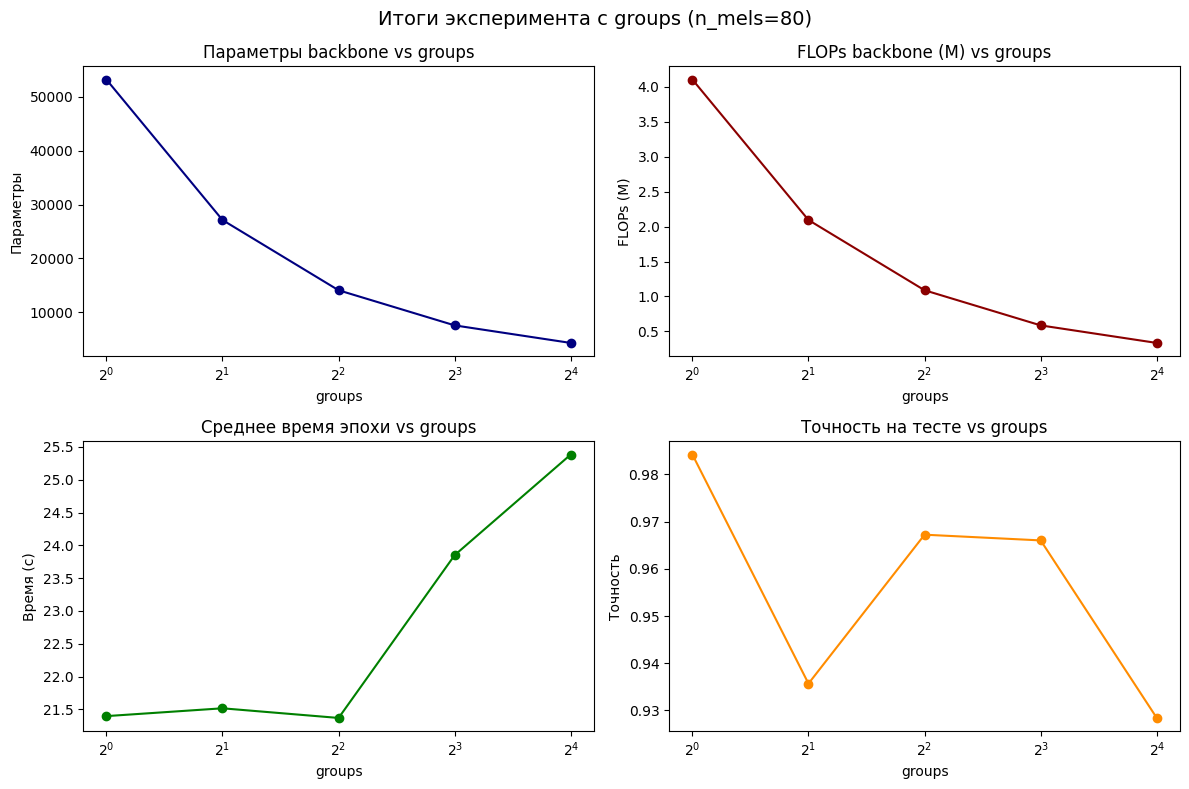

  groups |     params |  FLOPs (M) | epoch_time |   test_acc
------------------------------------------------------------
       1 |     53,250 |       4.11 |      21.40 |     0.9842
       2 |     27,138 |       2.09 |      21.52 |     0.9357
       4 |     14,082 |       1.09 |      21.37 |     0.9672
       8 |      7,554 |       0.59 |      23.85 |     0.9660
      16 |      4,290 |       0.34 |      25.38 |     0.9284


In [33]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Влияние параметра groups (n_mels=80)', fontsize=14)

for g, result in groups_results.items():
    h = result['history']
    axes[0].plot(h['train_loss'],  label=f'groups={g}')
    axes[1].plot(h['val_acc'],     label=f'groups={g}')
    axes[2].plot(h['epoch_time'],  label=f'groups={g}')

for ax, title, ylabel in zip(axes,
      ['Ошибка на обучении', 'Точность на валидации', 'Время эпохи (с)'],
      ['Ошибка', 'Точность', 'Секунды']):
      ax.set_title(title); ax.set_xlabel('Эпоха'); ax.set_ylabel(ylabel); ax.legend()

plt.tight_layout()
plt.savefig('groups_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary: params, FLOPs, epoch time, test accuracy vs groups
params_list     = [groups_results[g]['backbone_params'] for g in GROUPS_LIST]
flops_list      = [groups_results[g]['flops']           for g in GROUPS_LIST]
epoch_time_list = [np.mean(groups_results[g]['history']['epoch_time']) for g in GROUPS_LIST]
test_acc_list   = [groups_results[g]['test_acc']        for g in GROUPS_LIST]

fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8))
fig2.suptitle('Итоги эксперимента с groups (n_mels=80)', fontsize=14)

axes2[0, 0].plot(GROUPS_LIST, params_list, 'o-', color='navy')
axes2[0, 0].set_title('Параметры backbone vs groups')
axes2[0, 0].set_xlabel('groups'); axes2[0, 0].set_ylabel('Параметры')
axes2[0, 0].set_xscale('log', base=2)

if all(f is not None for f in flops_list):
    axes2[0, 1].plot(GROUPS_LIST, [f / 1e6 for f in flops_list], 'o-', color='darkred')
    axes2[0, 1].set_title('FLOPs backbone (М) vs groups')
    axes2[0, 1].set_xlabel('groups'); axes2[0, 1].set_ylabel('FLOPs (М)')
    axes2[0, 1].set_xscale('log', base=2)
else:
    axes2[0, 1].text(0.5, 0.5, 'FLOPs unavailable', transform=axes2[0, 1].transAxes, ha='center')

axes2[1, 0].plot(GROUPS_LIST, epoch_time_list, 'o-', color='green')
axes2[1, 0].set_title('Среднее время эпохи vs groups')
axes2[1, 0].set_xlabel('groups'); axes2[1, 0].set_ylabel('Время (с)')
axes2[1, 0].set_xscale('log', base=2)

axes2[1, 1].plot(GROUPS_LIST, test_acc_list, 'o-', color='darkorange')
axes2[1, 1].set_title('Точность на тесте vs groups')
axes2[1, 1].set_xlabel('groups'); axes2[1, 1].set_ylabel('Точность')
axes2[1, 1].set_xscale('log', base=2)

plt.tight_layout()
plt.savefig('groups_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f'{'groups':>8} | {'params':>10} | {'FLOPs (M)':>10} | {'epoch_time':>10} | {'test_acc':>10}')
print('-' * 60)
for g, p, f, t, a in zip(GROUPS_LIST, params_list, flops_list, epoch_time_list, test_acc_list):
    f_str = f'{f/1e6:.2f}' if f is not None else 'N/A'
    print(f'{g:>8} | {p:>10,} | {f_str:>10} | {t:>10.2f} | {a:>10.4f}')

## Выводы

### Вывод по классу LogMelFilterBanks
Реализован слой LogMelFilterBanks на базе torch.stft и torchaudio.functional.melscale_fbanks. Слой принимает батч аудиосигналов формы (batch, time) и возвращает логарифм мел-спектрограммы формы (batch, n_mels, n_frames).

Корректность реализации проверена сравнением с эталонной torchaudio.transforms.MelSpectrogram: максимальное абсолютное отклонение составило 9.54e-07, что соответствует погрешности числа с плавающей точкой и подтверждает идентичность реализаций.
### Выводы по эксперементу от числа мел-филтров
Проведены эксперименты с n_mels ∈ {20, 40, 80} при фиксированном groups=1.

Для данной задачи бинарной классификации «yes» / «no» увеличение числа мел-фильтров сверх 20 избыточно: различия в итоговой точности между конфигурациями невелики. При
n_mels=20 модель демонстрирует наименьшую ошибку на обучении и более стабильную сходимость — кривая точности на валидации имеет меньше скачков по сравнению с n_mels=40
и n_mels=80. Впрочем, эта нестабильность при больших значениях может быть частично объяснена шумом внутри самого датасета, а не архитектурными причинами.

Таким образом, для простых задач бинарной классификации речи компактное представление (n_mels=20) оказывается достаточным и при этом снижает вычислительную нагрузку.

### Вывод по эффекту от групп
Проведены эксперименты с groups ∈ {1, 2, 4, 8, 16} при фиксированном n_mels=80.

С ростом groups число параметров и FLOPs backbone снижаются практически линейно: при groups=16 модель содержит в 12 раз меньше параметров (4 290 против 53 250) и       
потребляет в 12 раз меньше FLOPs (0.34М против 4.11М) по сравнению с baseline.

Время эпохи при этом не уменьшается, а наоборот — слегка растёт (с 21.4 до 25.4 с). Это объясняется тем, что групповые свёртки менее эффективно утилизируют GPU:        
параллелизм внутри каждой группы ниже, и накладные расходы на синхронизацию перевешивают выигрыш от меньшего числа операций.

Точность на тесте остаётся высокой вплоть до groups=8 (0.966), и заметно падает только при groups=16 (0.928). Наилучший баланс между компактностью и качеством
показывает конфигурация groups=4: сокращение параметров в 3.8 раза и FLOPs в 3.8 раза при потере точности менее 2% относительно baseline.